# Return curves of each option and env reward

In [41]:
# get data - download and store locally 
import wandb
import os
from dotenv import load_dotenv
# load environment variables from .env file
load_dotenv()
# use .env for the api key
api_key =  os.getenv("WANDB_API_KEY")
api = wandb.Api(api_key=api_key)
# run = api.run("raban-emunds-tu-darmstadt/uncategorized/runs/g304pm83") 
run = api.run("raban-emunds-tu-darmstadt/uncategorized/runs/4nimiw1j") 

In [ ]:
seeds = [1078027127, 1416732029, 1524306142, 1836460763, 3297765038]
seeds = ["rng" + str(seed) for seed in seeds] 

In [ ]:
metrics = ["returned_episode_env_returns", "returned_episode_returns_0", "returned_episode_returns_1", "returned_episode_returns_2"]
keys = [seed + "/" + metric for metric in metrics for seed in seeds] 

run_data = run.history(keys=["returned_episode_env_returns", "returned_episode_returns_0",
                             "returned_episode_returns_1", "returned_episode_returns_2",])
x_data = run_data["_step"].to_numpy() / 1000
env_ret = run_data["returned_episode_env_returns"].to_numpy()
# env_ret = env_ret - env_ret.min()) # normalize 
shoot_enemies_ret = run_data["returned_episode_returns_0"].to_numpy()
shoot_enemies_ret = (shoot_enemies_ret - shoot_enemies_ret.min()) / shoot_enemies_ret.max()  # normalize
collect_divers_ret = run_data["returned_episode_returns_1"].to_numpy()
collect_divers_ret = (collect_divers_ret - collect_divers_ret.min()) / collect_divers_ret.max() # normalize 
surface_ret = run_data["returned_episode_returns_2"].to_numpy()
surface_ret = (surface_ret - surface_ret.min()) / surface_ret.max()  # normalize

In [ ]:
# TODO: average over multiple seeds -> rerun exps with the seeds function for that

/tmp/ipykernel_3637114/561602591.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10")
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfo

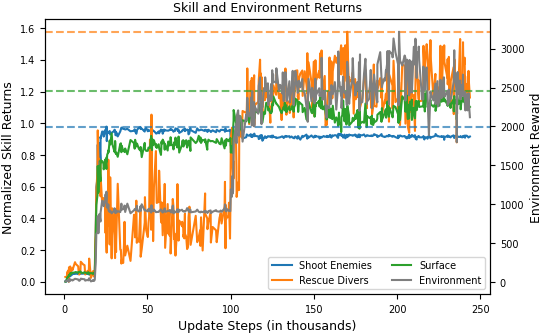

In [77]:
import matplotlib.pyplot as plt
from tueplots import bundles
from matplotlib import cm

max_env_ret = env_ret.max()
max_shoot_enemies_ret = shoot_enemies_ret.max()
max_collect_divers_ret = collect_divers_ret.max()
max_surface_ret = surface_ret.max()

colors = cm.get_cmap("tab10")

with plt.rc_context(bundles.neurips2024(usetex=False)):
    fig, ax1 = plt.subplots()
    ax1.plot(x_data, shoot_enemies_ret, label="Shoot Enemies", color=colors(0), zorder=1) 
    ax1.plot(x_data, collect_divers_ret, label="Rescue Divers", color=colors(1), zorder=1)
    ax1.plot(x_data, surface_ret, label="Surface", color=colors(2), zorder=1) 
    
    # Add dotted horizontal lines at the maximum values
    ax1.axhline(max_shoot_enemies_ret, color=colors(0), linestyle="--", alpha=0.7, zorder=1)
    ax1.axhline(max_collect_divers_ret, color=colors(1), linestyle="--", alpha=0.7, zorder=1)
    ax1.axhline(max_surface_ret, color=colors(2), linestyle="--", alpha=0.7, zorder=1)
    ax1.set_xlabel("Update Steps (in thousands)")
    ax1.set_ylabel("Normalized Skill Returns")

    # Create a second y-axis for the environment reward
    ax2 = ax1.twinx()
    ax2.plot(x_data, env_ret, label="Environment", color=colors(7), zorder=1)  # Brown
    # ax2.axhline(max_env_ret, color=colors(7), linestyle="--", alpha=0.7, zorder=1)
    ax2.set_ylabel("Environment Reward")
    
    # Combine legends from both axes and ensure they are drawn on top of the lines
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    legend = ax1.legend(lines_1 + lines_2, labels_1 + labels_2, ncol=2)
    legend.set_zorder(2)  # Ensure the legend is drawn on top of the lines
    
    plt.title("Skill and Environment Returns")
    plt.show()

In [ ]:
# TODO: Compare with PPO and maybe PQN? -> What about nudge or similar?
# Interesting: does it converge faster? Does it perform better / on par?
